<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-celeste/Tarea3_AproximacionApophis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<img src="https://drive.google.com/uc?id=1ZHUKcwzA5c-PKUwoGmBG3TsHk6TmZ-Y0" align="left" width="250">
</p><p><br>

<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 3</center></b><h2>
<h3><b><center>La aproximación de Apophis</center></b><h3>
<h5><center><b>Asignada</b>: 19 de Septiembre de 2023</center><h5>
<h5><center><b>Entrega</b>: 3 de Octubre de 2023</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 3-10-23
<hr/>
<br>


In [ ]:
# Instalacion de librerias
!pip install -q pymcel  # libreria general del profe

In [ ]:
# librerias
import pymcel as pc
import numpy as np
import pandas as pd
import spiceypy as spy
import matplotlib.pyplot as plt
import plotly.graph_objects as go # 3d

from tqdm import tqdm # control de tiempos
from astropy.time import Time # formato de tiempo
from scipy.signal import argrelextrema # extremos de funciones
from astroquery.jplhorizons import Horizons # efemerides
from astropy import constants as cte, units as u # constantes

In [ ]:
# Parametros y constantes importantes
rad   = np.pi/180      # [°] a [rads]
deg   = 1/rad          # [rads] a [°]
au    = cte.au.value   # [m]
G     = cte.G.value    # [m^3/s^2*kg]
day_2_s = 24*60*60     # [dias] a [s]
s_2_day = 1/day_2_s    # [s] a [dias]
year_2_day = 365.25    # [años] a [dias]

### **Objetivo**:
El objetivo de esta tarea es utilizar la solución analítica del problema de los dos cuerpos para estudiar la aproximación del asteroide peligroso **99942 Apophis (2004 MN4)** durante el 13 de abril del año 2029.
<br><br>


#### **Unidades Canonicas**
Se tomaron las siguientes unidades de modo que $G=1 [U_l^3/U_t^2*U_m]$

> $\left\{\begin{matrix}
U_l = & 1 \quad [AU]      \\
U_m = &  1 \quad [M_{\odot}] \\
U_t ≈  &  \quad 58.13 [dias]
\end{matrix}\right.$

In [ ]:
# unidades canonicas (G = 1 [U_l^3/U_t^2*U_m] )
U_l = au                     # [m]
U_m = cte.M_sun.value        # [kg]
U_t = (U_l**3/(G*U_m))**0.5  # [s]

# Unidades derivadas
U_v = U_l/U_t                # [U_l/U_t]
Ut_day = U_t*s_2_day         # [dias]

# μ en unidades canónicas
μ = 1                        # [U_l^3/U_t^2]



###**Procedimiento**:

1. Obtenga el vector de estado del asteroide Apophis el día de su cumpleaños en 2023 a las 00:00:00 UTC con respecto al Sol, así como el vector de estado de la Tierra respecto al mismo sistema de referencia.

In [ ]:
# parametros iniciales de los objetos a estudiar
jd = Time('2023-04-23 00:00:00').jd # tiempo inicial [jd] '2029-03-23 00:00:00'

ids = ['399','99942']               # ids de objetos
names = ['Tierra','Apophis']        # nombres objetos
N = len(ids)                        # numero de objetos


def query_inicial( jd ):

  T = np.zeros(N)                     # periodos orbitales
  r_vec = [] ; r = []                 # vector r y magnitud
  v_vec = [] ; v = []                 # vector v y magnitud
  elements_horizons = []              # elements orbitales de horizons

  for i in range(len(ids)): # para cada objeto
    # query y vector de estado

    query = Horizons(id=ids[i], location='@10', epochs= jd )
    state_i = query.vectors().to_pandas()

    # vectores (r,v) inicial [u. canonicas]
    r_vec.append( np.array( state_i[['x','y','z']]*au/U_l )[0] )
    v_vec.append( np.array( state_i[['vx','vy','vz']]*(au/day_2_s)/U_v )[0] )
    r.append( np.linalg.norm(r_vec[i]) ) # magnitudes r y v
    v.append( np.linalg.norm(v_vec[i]) )


    # elementos orbitales (Horizons)
    elements_horizons.append( query.elements().to_pandas() )
    T[i] = elements_horizons[i].loc[0,'P']  # periodos [dias]

  return r_vec, r, v_vec, v, T


### **Elementos Orbitales**

2. Determine los elementos orbitales del asteroide y los elementos órbitales osculatrices de la Tierra usando el procedimiento aprendido en clase. Estos elementos orbitales serán los que usará a partir de ahora en todos los cálculos que use la teoría del problema de los dos cuerpos. Es importante que use el procedimiento en clase en lugar de obtener simplemente los elementos de astroquery.
<br><br>

##### **Funcion de determinacion de los elementos orbitales ($p,e,f,Ω,I,ω$)**
Tomando como inputs los vectores posicion, velocidad y sus respectivas magnitudes ( calculadas con la funcion previa ```query_inicial```), se creó la funcion ```orbital_elements``` que con el procedimiendo del capitulo de los 2-cuerpos calcula los elementos orbitales principales; los angulares con sus respectivas correciones de cuadrante, empleando una pequeña funcion llamada ```primer_circulo``` para corregir angulos fuera del rango comun o en caso de ser negativos. Finalmente la funcion retorna un Dataframe con los elementos principales. (nota: el nombre de algunos elementos seguido de "_p" indica el su valor principal ) tambien se agrego una funcion similar a la de la tarea anterior para el calculo de vectores relativos ```vec_relativo```

In [ ]:
# funciones utiles

def primer_circulo(a):                     # [rads]
  a = a - int(a/(2*np.pi))*2*np.pi         # a primer circulo
  if a < 0: a = a + 2*np.pi                # caso angulo negativo
  return a                                 # [rads]

def vec_relativo( A ):                     # vector Relativo y Magnitud
  A_rel = A[0] - A[1]
  A_mag = np.linalg.norm( A_rel, axis=1 )
  return A_rel, A_mag

In [ ]:

def orbital_elements(r_vec, r, v_vec, v):

  # vectores cuadratura 2-cuerpos
  h_vec = np.cross(r_vec, v_vec)              # mare
  e_vec = np.cross(v_vec, h_vec)/μ - r_vec/r  # vector de laplace
  n_vec = np.cross([0,0,1], h_vec)            # vector de nodos

  # magnitudes de cuadraturas
  e = np.linalg.norm(e_vec) # exentricidad
  h = np.linalg.norm(h_vec)
  n = np.linalg.norm(n_vec)

  # elementos orbitales (angulares) [rad]
  I   = np.arccos(h_vec/h @ [0,0,1])          # inclinacion
  Ω_p = np.arccos(n_vec/n @ [1,0,0])          # nodo ascendente
  ω_p = np.arccos(n_vec/n @ e_vec/e)          # argumento de periapsis
  f_p = np.arccos(e_vec/e @ r_vec/r)          # anomalia verdadera

  # correcion de cuadrante, angulos en rango [0,2π]
  Ω = Ω_p if n_vec[1]>=0   else 2*np.pi - Ω_p
  ω = ω_p if e_vec[2]>=0   else 2*np.pi - ω_p
  f = f_p if r_vec@v_vec>0 else 2*np.pi - f_p


  # elementos orbitales (longitud) [U_l]
  p = h**2/μ              # semilatus rectus
  a = p/(1-e**2)          # semieje mayor
  q = p/(1+e)             # distancia periapsis
  Q = 2*a - q             # distancia apoapsis

  # anomalias Excentrica (E) y Media (M) iniciales [rads]
  E = 2*np.arctan( np.tan(f/2) * ((1-e)/(1+e))**0.5 )
  E = primer_circulo(E)   # correcion de cuadrante
  M = E - e*np.sin(E)
  M = primer_circulo(M)   # correcion de cuadrante

  # Devuelve dataframe con los elementos
  return pd.DataFrame({'I [rad]':I,'Ω [rad]':Ω,'ω [rad]':ω,
                       'f [rad]':f,'a [U_l]':a,'e [U_l]':e,
                       'E [rad]':E,'M [rad]':M,'h':h,'p':p}, index=[0])



### **Prediccion en el Tiempo: MOID y su respectiva fecha**

3. Usando los elementos orbitales de ambos cuerpos determine la mínima distancia a la que se encontarán ambas órbitas en cualquier momento del futuro. A esta distancia se la llama MOID, por el acrónimo en inglés *Minimum orbital intersection distance*.



4. Para saber cuándo se producirá la máxima aproximación entre los dos cuerpos es necesario sin embargo resolver el problema de los dos cuerpos en el tiempo. Para ello use la ecuación de Kepler y los métodos aprendidos en clase para propagar hacia el futuro la posición de la Tierra y del asteroide en el tiempo y determinar la fecha, hora y distancia de la próxima aproximación. Para ello avance primero de mes en mes por ejemplo, y luego, cerca a la aproximación máxima, de día en día, de hora en hora, hasta encontrar el punto de mínima distancia. ¿En qué fecha, hora y distancia predice usted que se producirá la máxima aproximación?



De una forma general, se requiere resolver el problema de los 2-cuerpos en el tiempo, por lo que se creo una funcion ```prediccion_2cuerpos``` que dada una fecha de inicio [dias], un rango total de tiempo [años], un tamaño de paso [dias], y el vector de estado inicial encontrado con la funcion query_inicial, y empleando la funcion para los elementos orbitales soluciona el problema de los 2-cuerpos en el tiempo, que en resumen se puede ver de la siguiente forma: parte del vector de estado, enceuntra las anomalias, usa la ecuacion de kepler para encontrar las anomalias en un tiempo futuro, para finalmente dar con el vector de estado futuro usando las ecuaciones rotadas para $\vec{r}$ y las ecuaciones del hodografo.

$$\vec{X} \rightarrow  f,E,M \Rightarrow_{futuro}\Rightarrow  M_f,E_f,f_f \rightarrow  \vec{X}_f$$ <br>



En adelante se emplearon funciones para intentar hacer un proceso recursivo para refinar la fecha y el valor del MOID, no solo para un rango de tiempo fijo.


In [ ]:

def prediccion_2cuerpos(jd, year_f, step_int, r_vec,r,v_vec,v,T):

  dias_f = year_f * year_2_day  # dias de prediccion
  jd_f   = jd + dias_f          # tiempo final [dias]
  t = np.arange(jd, jd_f-step_int, step_int) # rango de tiempo

  obj_elment = [] # elementos orbitales para cada objeto

  # vectores finales cada objeto en sistema observador
  r_vecf = np.zeros((len(ids), len(t), 3)) # pos
  v_vecf = np.zeros((len(ids), len(t), 3)) # vel

  for i in range(len(ids)): # para cada objeto
    r_vecf[i][0] = r_vec[i] # incluyendo pos inicial

    # Elementos orbitales iniciales
    obj_elment.append( orbital_elements( r_vec[i], r[i], v_vec[i], v[i]) )
    Ω,ω,I,M,E,e,a,h,p = obj_elment[i].loc[0,['Ω [rad]','ω [rad]','I [rad]',
                                            'M [rad]','E [rad]','e [U_l]',
                                            'a [U_l]','h','p']]

    # velocidad angular media n [rad/dia]
    n = 2*np.pi/T[i]           # opcion 1

    # matriz de rotacion inverza (natural->observador)
    M_inv = spy.eul2m(-Ω,-I,-ω, 3,1,3)

    # vectores estado futuros (sistema natural)
    r_ppp  = np.zeros((len(t)-1 , 3))
    v_ppp  = np.zeros((len(t)-1 , 3))


    for j in tqdm(range(len(t)-1)):  # prediccion en cada tiempo
      # Anomalias futuras + correcion de cuadrante [rads]
      M_f = primer_circulo( M + n*(t[j+1] - t[0]) )

      E_f, er, iter = pc.kepler_newton(M_f, e, delta=1e-14)
      E_f = primer_circulo( E_f )

      f_f = 2*np.arctan( np.tan(E_f/2) * ((1+e)/(1-e))**0.5 )
      f_f = primer_circulo( f_f )

      # vector estado (sistema natural)
      r_f = p/(1+e*np.cos(f_f)) # nueva magnitud r
      r_ppp[j] = [r_f*np.cos(f_f), r_f*np.sin(f_f), 0]        # r rotado
      v_ppp[j] = [-μ/h*np.sin(f_f), μ/h*(e + np.cos(f_f)), 0] # hodografo

      # vector estado (sistema observador)
      r_vecf[i][j+1] = spy.mxv( M_inv, r_ppp[j] )
      v_vecf[i][j+1] = spy.mxv( M_inv, v_ppp[j] )

  r_rel, r_mag = vec_relativo( r_vecf ) # vectores relativos futuros

  return r_rel, r_mag, t, jd_f



#### **Datos reales astroquery** <br>

Para obtener el vector de estado de Astroquery el tiempo inicial y final usandos para la prediccion anterior se transforman a formato utc string para poder ingresarlas en Astroquety. El fromato de conversion ```Time(jd, format='jd', scale='utc').datetime``` para la conversion fue tomado de chat gpt, al no ser el principal objetivo del presnete notebook. Ademas se resta $1$ paso al tiempo final para hacer coincidir el tamaño del rango de tiempos de la prediccion anterior. Por otro lado, en la conversion a formato string irregularmente aparece un mensaje de dubious year, que ejecutando la conversion por separado no aparecia, por lo que se tomó el siguiente fragmento de codigo recuperado de chat gpt para silenciarlos.



In [ ]:
# @title Silenciar warning de formato string

import warnings

# Función para silenciar el warning "dubious year" de ERFA
def silenciar_warning_dubious_year(message, category, filename,
                                   lineno, file=None, line=None):pass

# Configura el filtro de warnings para silenciar "dubious year"
warnings.filterwarnings("ignore", category=UserWarning, module="erfa")
warnings.showwarning = silenciar_warning_dubious_year

In [ ]:
def prediccion_astroquery(jd, jd_f, step_s, step_int):

  # condiciones de tiempo
  to = str(Time(jd, format='jd', scale='utc').datetime)
  tf = str(Time(jd_f - step_int, format='jd', scale='utc').datetime)

  r_astroquery = [] # posicion futura

  for i in tqdm(range(len(ids))): # para cada objeto
    query_f = Horizons(id=ids[i], location='@10',
                      epochs = dict(start = str(to),
                                    stop = str(tf),
                                    step = str(step_s))).vectors().to_pandas()

    r_astroquery.append( query_f[['x','y','z']])

  # tiempo en formato para graficar [años]
  times = query_f['datetime_str']
  ts = [pd.to_datetime(times[k][3:]) for k in range(len(times))]

  # vector relativo y magnitud
  r_rel_real, r_mag_real = vec_relativo( r_astroquery )

  return r_rel_real, r_mag_real, ts



#### Distancia relativa tierra-apophis y MOID

Con los vectores de estado calculados con la anterior funcion, basta con calcular los vectores relativos de ambos objetos (tierra-apophis), su magnitud, y con la funcion ```min``` encontrar el valor de aproximacion minima, que seria el valor del MOID, junto con su respectivo indice para dar con el tiempo correspondiente donde ocurre este evento. Tambien se agrega una grafica para la distancia relativa entre los dos cuerpos en funcion del tiempo, junto con su error absoluto.

In [ ]:
def calculo_MOID(r_mag, r_mag_real, ts, t):
  err = np.abs(r_mag - r_mag_real) # error absoluto

  # Distancia minima de interseccion orbital MOID
  MOID = min(r_mag)            # 2 cuerpos
  MOID_query = min(r_mag_real) # astroquery

  err_MOID = (MOID-MOID_query)

  # indice del MOID en el arreglo
  i_MOID       = np.where(r_mag==MOID)[0][0]              # 2 cuerpos
  i_MOID_query = np.where(r_mag_real == MOID_query)[0][0] # astroquery


  # graficando distancia relativa y su error absoulto
  plt.style.use('seaborn-v0_8-dark-palette')
  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

  ax[0].set_title('Distancia relativa Tierra-Apophis')
  ax[0].plot( ts, r_mag_real, 'r', label ='Astroquery')
  ax[0].plot( ts, r_mag, label='2-cuerpos')
  ax[0].set_ylabel('[AU]')
  ax[0].legend()
  ax[0].grid()

  ax[1].set_title('Error distancia relativa Tierra-Apophis')
  ax[1].set_ylabel('[AU]')
  ax[1].plot( ts, err)
  ax[1].grid()

  print(f'\nFecha MOID (2cuerpos): {ts[i_MOID]},  MOID: {MOID} [AU]' )
  print(f'Fecha MOID (Astroquery): {ts[i_MOID_query]}, MOID: {MOID_query} [AU]')
  print(f'Error en MOID: {err_MOID}\n')

  return err_MOID, i_MOID, t[i_MOID]



#### **Iterando**

Finalmente se crea una funcion que emplea en cadena todas las anteriores funciones para calcular el MOID, la fecha en la que se dá y graficar la distancia relativa entre los dos cuerpos, imprime estos valores y retorna la aproximacion de la fecha del MOID dado la fecha inicial [dias julianos], el rango de tiempo a estudiar[años], el paso de la prediccion (step_int) [dias], el formato del paso de la prediccion (u_step) y el paso en formato string para astroquery.

In [ ]:

def iteracion_MOID(jdo,year_f,step_int,u_step,step_s):
  r_vec, r, v_vec, v, T = query_inicial(jdo)
  r_rel, r_mag, t, jd_f = prediccion_2cuerpos(jdo, year_f, step_int,
                                              r_vec,r,v_vec,v,T)

  r_rel_real, r_mag_real, ts = prediccion_astroquery(jdo, jd_f,
                                                     step_s, step_int)

  if len(ts) > len(t): # condicion tamaño de tiempo igual
      r_rel_real = r_rel_real[:-1]
      r_mag_real = r_mag_real[:-1]
      ts = ts[:-1]

  err_MOID, i_MOID, t_i = calculo_MOID(r_mag, r_mag_real, ts, t)

  return t_i

100%|██████████| 2/2 [00:00<00:00, 36.42it/s]



Fecha MOID (2cuerpos): 2029-04-11 00:00:00,  MOID: 0.032956992788459115 [AU]
Fecha MOID (Astroquery): 2029-04-11 00:00:00, MOID: 0.010066165479215055 [AU]
Error en MOID: 0.02289082730924406



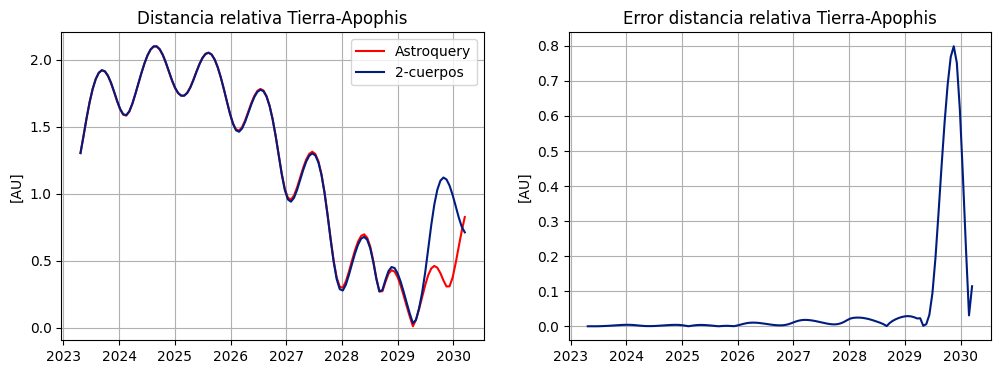

In [ ]:
# Iteracion 1

jd = Time('2023-04-23 00:00:00').jd # fecha inicial [dias]
year_f = 7                          # intervalo tiempo [años]
step_int = 20                       # paso mas preciso [20d]
u_step = "d"                        # formato de paso [d]
step_s = str(20) + u_step           # paso en string [20d]

jd_moid = iteracion_MOID(jd,year_f,step_int,u_step,step_s)


100%|██████████| 2/2 [00:00<00:00,  4.27it/s]



Fecha MOID (2cuerpos): 2029-04-13 23:00:00,  MOID: 0.00029859708938961035 [AU]
Fecha MOID (Astroquery): 2029-04-13 22:00:00, MOID: 0.00025675954020195767 [AU]
Error en MOID: 4.183754918765268e-05



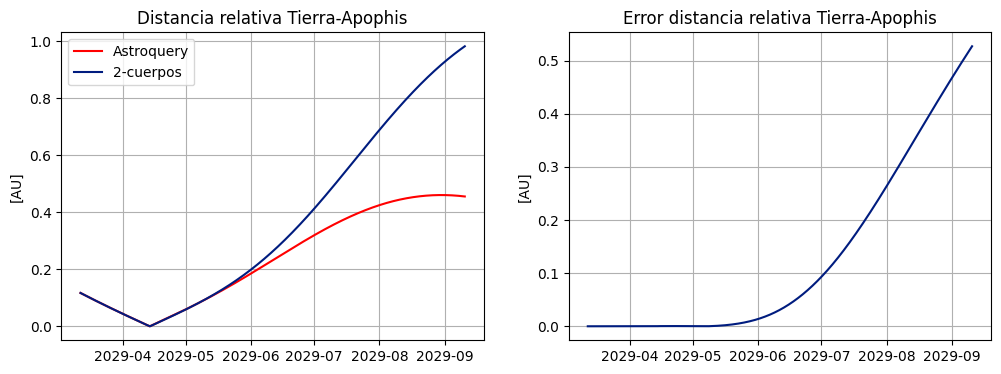

In [ ]:
# Iteracion 2

jd2 = jd_moid-30            # nueva fecha inicial [dias]
year_f2 = 1/2               # intervalo mas corto  [año]
step_int2 = 1/24            # paso mas preciso [1h]
u_step2 = "h"               # formato de paso [hora]
step_s2 = str(1) + u_step2  # paso en string [1h]


jd_moid_new = iteracion_MOID(jd2,year_f2,step_int2,u_step2,step_s2)

5. Una vez encontrada la fecha y hora de la aproximación obtenida con el problema exclusivamente con la solución analítica del problema de los dos cuerpos (la que estamos viendo aquí), compárela con la que se obtiene recuperando de astroquery las posiciones de la Tierra y Apophis desde su cumpleaños hacia el futuro. Es decir, repita el procedimiento anterior, pero en lugar de obtener las posiciones a partir de la teoría del problema de los dos cuerpos, recupere las posiciones usando astroquery.  ¿Qué tan diferentes son los resultados de este procedimiento y del anterior? ¿podría explicar las discrepancias?

###**Conclusiones**

Lo primero a reconocer es que la aproximacion para los vectores de estado dado cierto rango de tiempo de prediccion, tiende a acumular mas error a medida que se proyecta en un rango de tiempo mayor, que se debe entre otras cosas a que en la realidad el sistema no se trata estrictamente de uno aislado de 2 cuerpos, por lo que la influencia gravitacional de otros cuerpos puede afectar los resultados, junto con el cambio en los elementos orbitales, los errores se acumulan, como se puede apreciar al final de las predicciones en las graficas. Sin embargo, tomando un rango de tiempo razonable y un tamaño de paso lo suficientemente pequeño para que aumenten la presicion, como resultó en la segunda aproximacion, con un orden de magnitud en error en el MOID de aproximadamente $10^{-5}$, y una diferencia de una hora en la fecha de ocurrencia del MOID, puede resultar en una buena primera aproximacion, a pesar de no ser exatamente la real del resultado del problema de n-cuerpos de Astroquery

Por otro lado, se pudo haber hecho una iteracion de forma mas automatica pero me queda como reto. Como agregado, el seguimiento de tiemposde tqdm es util al ser poaible poder tomar un rango de tiempo muy grande con un tamaño de paso pequeño.

<br>

___
<br>

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Datos mínimos:
  - MOID de la órbita de Apophis y de la Tierra calculado con la teoría del problema de los 2 cuerpos.
  - Fecha, hora y distancia mínima de aproximación calculado con la teoría del problema de los 2 cuerpos.
  - Fecha, hora y distancia mínima de aproximación calculado con los datos obtenidos de Astroqery.

- Gráficos mínimos:
  - Distancia entre Apophis y la Tierra como función del tiempo desde la fecha de nacimiento hasta la máxima aproximación, calculada con la teoría del problema de los dos cuerpos y con los datos de Astroquery.

- Gráficos opcionales:
  - Animaciones de la aproximación.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.